# 11 — External validation against ClinicalTrials.gov

Every metric so far (AUROC, AUPRC, precision@K) has been measured **inside** the Hetionet v1.0 snapshot: train on 604 known Compound-treats-Disease edges, evaluate on 151 held-out ones. Both halves come from the same 2015–2016 data compilation ([Himmelstein et al., eLife 2017](https://elifesciences.org/articles/26726)).

That answers *"can the model recover edges we deliberately hid?"* — but not the question that actually matters:

> **Do the model's high-scoring pairs that Hetionet labels `0` correspond to real drug–disease relationships?**

`nb03` already framed this correctly under the **open-world assumption**: `y = 0` does not mean "this drug cannot treat this disease". It means "as of 2016, nobody had recorded that it does". Some of those zeros are genuine negatives. Some are gaps in the knowledge graph. And some may be discoveries that happened *after* the snapshot.

This notebook tests that directly, using clinical trial registrations as the external ground truth.

## Design

| Element | Choice | Why |
|---|---|---|
| Predictions under test | GCN (nb08) scores on **test-set** pairs with `y = 0` | Test-set pairs were never used for supervision, so the model has no label information about them |
| External source | [ClinicalTrials.gov API v2](https://clinicaltrials.gov/data-api/api) | Free, complete since ~2007, covers "what did researchers actually try" |
| Control group | Popularity-matched random `y = 0` pairs | Without this, we would only be measuring "does the model rank famous drugs highly" — which nb06 §6a showed it does |
| Headline statistic | **Lift** = observed trials / expected trials given each side's marginal popularity | Directly removes the popularity confound |
| Strongest test | Trials that **started after 2017-01-01** | Hetionet was compiled 2015–2016, so these trials could not have leaked into the graph |

## Known measurement limits (state these before looking at any result)

1. **Name-matching false negatives.** Hetionet uses DrugBank compound names and Disease Ontology disease names. Trials are registered under trade names, combination-therapy names, or modality names. Verified example: `Methoxsalen × vitiligo` returns 0 trials, even though methoxsalen-based PUVA therapy is a standard vitiligo treatment — the trials are registered as "PUVA" or "psoralen".
2. **Registration-era blind spot.** ClinicalTrials.gov became mandatory in 2007. Treatments established earlier (e.g. `Sulfadiazine × malaria`, 1940s) show 0 trials despite being real.
3. **Trial ≠ efficacy.** A registered trial means somebody thought the pair was worth testing, not that it worked. This is a measure of *hypothesis plausibility*, not clinical validity.

Limits 1 and 2 reduce sensitivity, but they apply **equally to the prediction group and the control group**, so the comparison between the two remains valid. Limit 3 constrains how the result may be phrased.

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, time, urllib.parse, urllib.request, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART = pathlib.Path("artifacts")
EXT = ART / "external"; EXT.mkdir(parents=True, exist_ok=True)   # API response cache

HETIONET_CUTOFF = "2017-01-01"   # Hetionet v1.0 published 2017; data compiled 2015-2016

meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = int(meta["split_seed"])
rng = np.random.default_rng(SEED)
y = pairs["y"].to_numpy()

gcn = pd.read_parquet(ART / "predictions" / "gcn.parquet")
assert (gcn[["compound", "disease"]].values == pairs[["compound", "disease"]].values).all()
score_gcn = gcn["score_gcn"].to_numpy()

print(f"Pairs: {len(pairs):,} | positives: {int(y.sum())} | test pairs: {len(idx_test):,}")


Pairs: 206,312 | positives: 755 | test pairs: 41,263


## 2 · Resolve identifiers to names

Hetionet keys nodes by `(kind, identifier)`; the parquet files carry only the identifier. We need the human-readable names to query the trial registry, so load the raw graph once.

In [2]:
t0 = time.time()
hetnet = load_hetnet()
compound_name = {n["identifier"]: n["name"] for n in hetnet["nodes"] if n["kind"] == "Compound"}
disease_name  = {n["identifier"]: n["name"] for n in hetnet["nodes"] if n["kind"] == "Disease"}
print(f"Loaded hetnet in {time.time() - t0:.1f}s")
print(f"  compounds named: {len(compound_name):,}")
print(f"  diseases  named: {len(disease_name):,}")

pairs_named = pairs.copy()
pairs_named["compound_name"] = pairs_named["compound"].map(compound_name)
pairs_named["disease_name"]  = pairs_named["disease"].map(disease_name)
assert pairs_named["compound_name"].notna().all() and pairs_named["disease_name"].notna().all()
pairs_named.head(3)


Loaded hetnet in 12.2s
  compounds named: 1,552
  diseases  named: 137


,compound,disease,y,compound_name,disease_name
0,DB00014,DOID:0050156,0,Goserelin,idiopathic pulmonary fibrosis
1,DB00014,DOID:0050425,0,Goserelin,restless legs syndrome
2,DB00014,DOID:0050741,0,Goserelin,alcohol dependence


## 3 · The candidate set: top novel predictions

Restrict to the **test set**, drop the 151 true positives, and take the highest-scoring remaining pairs. These are exactly the pairs the model believes in but Hetionet does not record.

In [3]:
TOP_K = 100

test_view = pairs_named.iloc[idx_test].copy()
test_view["score_gcn"] = score_gcn[idx_test]
test_view["global_idx"] = idx_test

novel = test_view[test_view["y"] == 0].nlargest(TOP_K, "score_gcn").reset_index(drop=True)
print(f"Test-set pairs with y=0 : {int((test_view['y'] == 0).sum()):,}")
print(f"Selected top-{TOP_K} novel predictions by GCN score")
print(f"Score range in selection: [{novel['score_gcn'].min():.3f}, {novel['score_gcn'].max():.3f}]")
novel[["compound_name", "disease_name", "score_gcn"]].head(15)


Test-set pairs with y=0 : 41,112
Selected top-100 novel predictions by GCN score
Score range in selection: [6.701, 14.738]


,compound_name,disease_name,score_gcn
0,Dactinomycin,hematologic cancer,14.737729
1,Sulfasalazine,psoriasis,12.380971
2,Prednisone,coronary artery disease,11.969452
3,Acarbose,asthma,11.397718
4,Epirubicin,psoriasis,11.065462
5,Topotecan,breast cancer,10.655413
6,Cladribine,breast cancer,10.610574
7,Epirubicin,kidney cancer,10.514860
8,Methotrexate,pancreatic cancer,10.439005
9,Dexamethasone,breast cancer,10.435745


## 4 · Control sets — and why the obvious one is not enough

The naive control (uniformly random `y = 0` pairs) is clearly inadequate: nb06 §6a showed that high-scoring pairs skew toward high-degree nodes, and high-degree nodes have more trials. So we need matching.

The subtle trap is **which** popularity to match on. We build two controls and compare them:

- **Control A — graph-degree matched.** Match on walk-graph degree, the popularity signal the *model* sees.
- **Control B — trial-registry matched.** Match on how many trials each compound and each disease appears in overall, i.e. the popularity signal that drives the *outcome we are measuring*.

Control A is the intuitive choice and it is **not sufficient**, as §6 will show quantitatively. Control B is the one the headline number must be based on.

In [4]:
# Rebuild the walk graph (identical recipe to nb05 / nb08) purely to get node degrees
HUB_K = 20
KEEP_KINDS = {"Compound", "Gene", "Disease"}

G = nx.Graph()
for n in hetnet["nodes"]:
    if n["kind"] in KEEP_KINDS:
        G.add_node((n["kind"], n["identifier"]), kind=n["kind"])
kept = set(G.nodes())
for e in hetnet["edges"]:
    u, v = tuple(e["source_id"]), tuple(e["target_id"])
    if u in kept and v in kept:
        G.add_edge(u, v)

pos_mask  = y == 1
test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
for c, d in pairs.loc[pos_mask & test_mask, ["compound", "disease"]].itertuples(index=False):
    if G.has_edge(("Compound", c), ("Disease", d)):
        G.remove_edge(("Compound", c), ("Disease", d))

gene_deg = sorted(((n, deg) for n, deg in G.degree() if n[0] == "Gene"), key=lambda x: -x[1])
G.remove_nodes_from([n for n, _ in gene_deg[:HUB_K]])
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

deg = dict(G.degree())
for df in (novel, test_view):
    df["deg_c"] = [deg.get(("Compound", c), 0) for c in df["compound"]]
    df["deg_d"] = [deg.get(("Disease",  d), 0) for d in df["disease"]]

print(f"Walk graph for degrees: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")


Walk graph for degrees: 19,683 nodes, 525,174 edges


In [5]:
def matched_control(pred_df, pool_df, cols, n_bands=9, label=""):
    """Draw one control per prediction from the same (col1 band, col2 band) cell."""
    pool = pool_df.copy()
    c1, c2 = cols
    e1 = np.quantile(np.log10(pool[c1] + 1), np.linspace(0, 1, n_bands + 1))[1:-1]
    e2 = np.quantile(np.log10(pool[c2] + 1), np.linspace(0, 1, n_bands + 1))[1:-1]
    pool["b1"] = np.digitize(np.log10(pool[c1] + 1), e1)
    pool["b2"] = np.digitize(np.log10(pool[c2] + 1), e2)
    pr = pred_df.copy()
    pr["b1"] = np.digitize(np.log10(pr[c1] + 1), e1)
    pr["b2"] = np.digitize(np.log10(pr[c2] + 1), e2)

    rows, relaxed = [], 0
    for _, r in pr.iterrows():
        cand = pool[(pool["b1"] == r["b1"]) & (pool["b2"] == r["b2"])]
        if len(cand) == 0:
            cand = pool[pool["b1"] == r["b1"]]; relaxed += 1
        if len(cand) == 0:
            cand = pool
        pick = cand.sample(1, random_state=int(rng.integers(0, 2**31)))
        rows.append(pick.iloc[0])
        pool = pool.drop(pick.index)
    out = pd.DataFrame(rows).reset_index(drop=True)
    print(f"  control [{label}] drawn: {len(out)} pairs ({relaxed} relaxed matches)")
    return out


pool_base = test_view[(test_view["y"] == 0)
                      & (~test_view["global_idx"].isin(set(novel["global_idx"])))].copy()
control_deg = matched_control(novel, pool_base, ("deg_c", "deg_d"), label="graph degree")


  control [graph degree] drawn: 100 pairs (0 relaxed matches)


## 5 · Query ClinicalTrials.gov

Three numbers per pair:
- `n_trials` — total registered trials naming both the compound (as an intervention) and the disease (as a condition)
- `n_trials_post` — of those, how many started on/after `2017-01-01`
- `max_phase` — the most advanced phase reached

We also need each compound's and each disease's **marginal** trial count, both to build Control B and to compute lift. Responses cache to `artifacts/external/` so re-runs are free.

In [6]:
API = "https://clinicaltrials.gov/api/v2/studies"
CACHE_FILE = EXT / "ctgov_pair_cache.pkl"
_cache: dict = pickle.loads(CACHE_FILE.read_bytes()) if CACHE_FILE.exists() else {}
print(f"Loaded {len(_cache):,} cached queries.")


def _get(url: str, retries: int = 3):
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=30) as r:
                return json.load(r)
        except Exception:
            if attempt == retries - 1:
                return None
            time.sleep(1.5 * (attempt + 1))
    return None


def query_pair(drug: str, condition: str) -> dict:
    key = (drug.lower(), condition.lower())
    if key in _cache:
        return _cache[key]
    url = (f"{API}?query.intr={urllib.parse.quote(drug)}"
           f"&query.cond={urllib.parse.quote(condition)}"
           "&pageSize=200&countTotal=true&format=json"
           "&fields=NCTId,OverallStatus,Phase,StartDate")
    d = _get(url)
    if d is None:
        out = {"n_trials": np.nan, "n_trials_post": np.nan, "max_phase": None}
    else:
        studies = d.get("studies", [])
        n_post, phases = 0, []
        for s in studies:
            ps = s.get("protocolSection", {})
            start = ps.get("statusModule", {}).get("startDateStruct", {}).get("date", "")
            if start and start >= HETIONET_CUTOFF:
                n_post += 1
            phases.extend(ps.get("designModule", {}).get("phases", []))
        rank = {"PHASE1": 1, "PHASE2": 2, "PHASE3": 3, "PHASE4": 4}
        best = max((rank.get(p, 0) for p in phases), default=0)
        out = {"n_trials": int(d.get("totalCount", 0)), "n_trials_post": int(n_post),
               "max_phase": {0: None, 1: "PHASE1", 2: "PHASE2", 3: "PHASE3", 4: "PHASE4"}[best]}
    _cache[key] = out
    return out


def query_marginal(term: str, field: str) -> int:
    key = (field, term.lower())
    if key in _cache:
        return _cache[key]
    url = f"{API}?query.{field}={urllib.parse.quote(term)}&pageSize=1&countTotal=true&format=json"
    d = _get(url)
    n = int(d.get("totalCount", 0)) if d else 0
    _cache[key] = n
    return n


Loaded 2,618 cached queries.


In [7]:
# Marginal trial counts for every compound / disease in the test-set pool.
# ~1,650 queries at roughly 0.08 s each; instant once cached.
pool_full = test_view[test_view["y"] == 0].copy()
drugs = sorted(pool_full["compound_name"].unique())
conds = sorted(pool_full["disease_name"].unique())
print(f"Marginals needed: {len(drugs)} compounds, {len(conds)} diseases")

t0 = time.time()
for i, d in enumerate(drugs, 1):
    query_marginal(d, "intr")
    if i % 400 == 0:
        print(f"  compounds {i}/{len(drugs)}  ({time.time() - t0:.0f}s)")
for c in conds:
    query_marginal(c, "cond")
CACHE_FILE.write_bytes(pickle.dumps(_cache))
print(f"Marginals done in {time.time() - t0:.0f}s; cache now {len(_cache):,}")

for df in (novel, test_view, pool_base, control_deg):
    df["drug_marginal"] = [query_marginal(x, "intr") for x in df["compound_name"]]
    df["cond_marginal"] = [query_marginal(x, "cond") for x in df["disease_name"]]

# Control B: matched on trial-registry popularity instead of graph degree
control_pop = matched_control(novel, pool_base, ("drug_marginal", "cond_marginal"),
                              label="trial-registry popularity")


Marginals needed: 1517 compounds, 136 diseases
  compounds 400/1517  (0s)
  compounds 800/1517  (0s)
  compounds 1200/1517  (0s)
Marginals done in 0s; cache now 2,618


  control [trial-registry popularity] drawn: 100 pairs (0 relaxed matches)


In [8]:
def annotate(df: pd.DataFrame, label: str) -> pd.DataFrame:
    out = df.copy()
    recs = [query_pair(r.compound_name, r.disease_name) for r in out.itertuples(index=False)]
    res = pd.DataFrame(recs, index=out.index)
    print(f"  [{label}] annotated {len(out)} pairs")
    return pd.concat([out, res], axis=1)

novel_a   = annotate(novel,       "predictions")
ctrl_deg  = annotate(control_deg, "control A · graph degree")
ctrl_pop  = annotate(control_pop, "control B · trial popularity")
CACHE_FILE.write_bytes(pickle.dumps(_cache))
print(f"Cache: {len(_cache):,} entries")


  [predictions] annotated 100 pairs
  [control A · graph degree] annotated 100 pairs
  [control B · trial popularity] annotated 100 pairs
Cache: 2,618 entries


## 6 · Did the matching actually work?

Before reading any enrichment number, check that each control group is genuinely comparable to the prediction group on the axis it claims to match. A control that fails this check produces an inflated effect.

In [9]:
def match_report(pred, ctrl, name):
    rows = []
    for col, lab in [("deg_c", "graph degree · compound"), ("deg_d", "graph degree · disease"),
                     ("drug_marginal", "trial marginal · compound"),
                     ("cond_marginal", "trial marginal · disease")]:
        _, p = stats.mannwhitneyu(pred[col], ctrl[col], alternative="two-sided")
        rows.append({"control": name, "axis": lab,
                     "pred median": float(pred[col].median()),
                     "ctrl median": float(ctrl[col].median()),
                     "p": round(float(p), 4),
                     "comparable": "yes" if p > 0.05 else "NO — skewed"})
    return rows

match_df = pd.DataFrame(match_report(novel_a, ctrl_deg, "A · graph degree")
                        + match_report(novel_a, ctrl_pop, "B · trial popularity"))
match_df


,control,axis,pred median,ctrl median,p,comparable
0,A · graph degree,graph degree · compound,98.5,64.0,0.0408,NO — skewed
1,A · graph degree,graph degree · disease,630.0,630.0,0.7664,yes
2,A · graph degree,trial marginal · compound,598.0,115.5,0.0000,NO — skewed
3,A · graph degree,trial marginal · disease,7519.0,4041.5,0.0030,NO — skewed
4,B · trial popularity,graph degree · compound,98.5,19.0,0.0000,NO — skewed
5,B · trial popularity,graph degree · disease,630.0,301.0,0.0000,NO — skewed
6,B · trial popularity,trial marginal · compound,598.0,595.5,0.1987,yes
7,B · trial popularity,trial marginal · disease,7519.0,7519.0,0.7184,yes


**Read this table before anything else.** Control A matches the graph-degree rows but leaves the trial-marginal rows badly skewed — the model's top predictions involve compounds that are several times more studied in the registry than degree-matched controls. Since trial count *is* the outcome we measure, Control A cannot support a causal reading. Control B closes that gap.

### 6a · Enrichment under both controls

In [10]:
def summarise(df, name):
    return {
        "group": name,
        "n": len(df),
        "≥1 trial %":  round(100 * (df["n_trials"] > 0).mean(), 1),
        "post-2017 %": round(100 * (df["n_trials_post"] > 0).mean(), 1),
        "phase 2+ %":  round(100 * df["max_phase"].isin(["PHASE2", "PHASE3", "PHASE4"]).mean(), 1),
        "median trials (hits)": float(df.loc[df["n_trials"] > 0, "n_trials"].median() or 0),
    }

summary = pd.DataFrame([
    summarise(novel_a,  f"GCN top-{TOP_K} novel"),
    summarise(ctrl_deg, "control A · graph degree"),
    summarise(ctrl_pop, "control B · trial popularity"),
])
summary


,group,n,≥1 trial %,post-2017 %,phase 2+ %,median trials (hits)
0,GCN top-100 novel,100,60.0,47.0,56.0,7.0
1,control A · graph degree,100,31.0,20.0,24.0,4.0
2,control B · trial popularity,100,50.0,32.0,38.0,3.0


In [11]:
print(f"{'comparison':38s} {'pred':>8s} {'ctrl':>8s} {'enrich':>8s} {'Fisher p':>10s}")
print("-" * 76)
results_tbl = []
for cname, ctrl in [("A · graph degree", ctrl_deg), ("B · trial popularity", ctrl_pop)]:
    for lab, col in [("≥1 trial", "n_trials"), ("post-2017 trial", "n_trials_post")]:
        a = int((novel_a[col] > 0).sum()); b = int((ctrl[col] > 0).sum())
        _, p = stats.fisher_exact([[a, TOP_K - a], [b, TOP_K - b]], alternative="greater")
        enr = a / max(b, 1)
        print(f"{cname + ' | ' + lab:38s} {a:>7d}% {b:>7d}% {enr:>7.2f}x {p:>10.2e}")
        results_tbl.append({"control": cname, "metric": lab, "pred_hits": a, "ctrl_hits": b,
                            "enrichment": round(enr, 2), "fisher_p": float(p)})
print()
print("The drop from control A to control B is the size of the popularity confound.")


comparison                                 pred     ctrl   enrich   Fisher p
----------------------------------------------------------------------------
A · graph degree | ≥1 trial                 60%      31%    1.94x   3.14e-05
A · graph degree | post-2017 trial          47%      20%    2.35x   4.23e-05
B · trial popularity | ≥1 trial             60%      50%    1.20x   1.00e-01
B · trial popularity | post-2017 trial      47%      32%    1.47x   2.13e-02

The drop from control A to control B is the size of the popularity confound.


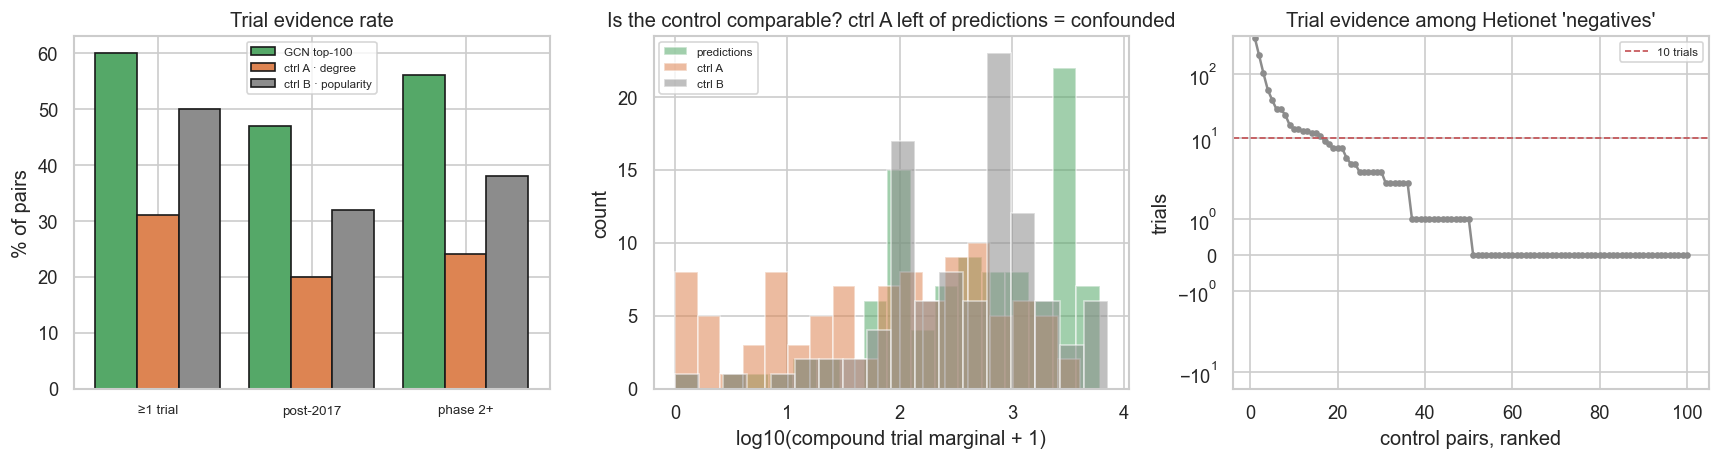

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))

labels = ["≥1 trial", "post-2017", "phase 2+"]
def vals(df):
    return [100 * (df["n_trials"] > 0).mean(),
            100 * (df["n_trials_post"] > 0).mean(),
            100 * df["max_phase"].isin(["PHASE2", "PHASE3", "PHASE4"]).mean()]
x = np.arange(3); w = 0.27
axes[0].bar(x - w, vals(novel_a),  w, label=f"GCN top-{TOP_K}", color="C2", edgecolor="k")
axes[0].bar(x,     vals(ctrl_deg), w, label="ctrl A · degree",  color="C1", edgecolor="k")
axes[0].bar(x + w, vals(ctrl_pop), w, label="ctrl B · popularity", color="C7", edgecolor="k")
axes[0].set(xticks=x, ylabel="% of pairs", title="Trial evidence rate")
axes[0].set_xticklabels(labels, fontsize=8); axes[0].legend(fontsize=7)

# Matching diagnostic: compound marginal distributions
for df, lab, col in [(novel_a, "predictions", "C2"), (ctrl_deg, "ctrl A", "C1"), (ctrl_pop, "ctrl B", "C7")]:
    axes[1].hist(np.log10(df["drug_marginal"] + 1), bins=18, alpha=0.55, label=lab, color=col)
axes[1].set(xlabel="log10(compound trial marginal + 1)", ylabel="count",
            title="Is the control comparable? ctrl A left of predictions = confounded")
axes[1].legend(fontsize=7)

# Label-noise view: how much trial evidence sits inside y=0
ctrl_sorted = np.sort(ctrl_pop["n_trials"].fillna(0).values)[::-1]
axes[2].plot(np.arange(1, len(ctrl_sorted) + 1), ctrl_sorted, marker="o", ms=3, color="C7")
axes[2].axhline(10, color="C3", ls="--", lw=1, label="10 trials")
axes[2].set(yscale="symlog", xlabel="control pairs, ranked", ylabel="trials",
            title="Trial evidence among Hetionet 'negatives'")
axes[2].legend(fontsize=7)
plt.tight_layout()


## 7 · Definitive analysis — match on all four axes at once

§6 exposed a problem the notebook cannot leave unresolved: **each control matched one axis and broke the other**. Control A balanced graph degree but left trial popularity skewed; Control B did the reverse. Neither supports a clean causal reading, and at n=100 the estimate also swings with the random draw.

The fix is to match on all four covariates simultaneously — `deg_c`, `deg_d`, `drug_marginal`, `cond_marginal` — using nearest-neighbour matching in standardised log space, and to raise the sample to **300 pairs per arm** so the estimate stops depending on which control happened to be drawn.

This section supersedes §6. The numbers here are the ones to report.

In [13]:
from scipy.spatial import cKDTree

N_ARM = 300
COV = ["deg_c", "deg_d", "drug_marginal", "cond_marginal"]

pool_full = test_view[test_view["y"] == 0].copy()
pool_full["drug_marginal"] = [query_marginal(x, "intr") for x in pool_full["compound_name"]]
pool_full["cond_marginal"] = [query_marginal(x, "cond") for x in pool_full["disease_name"]]

pred4 = pool_full.nlargest(N_ARM, "score_gcn").copy()
pool4 = pool_full.drop(pred4.index).copy()

# standardise in log space, then greedy nearest-neighbour match without replacement
Zall = np.log10(pd.concat([pred4, pool4])[COV].values + 1)
mu, sd = Zall.mean(0), Zall.std(0)
Zp = (np.log10(pred4[COV].values + 1) - mu) / sd
Zc = (np.log10(pool4[COV].values + 1) - mu) / sd

tree = cKDTree(Zc)
used, picked = set(), []
for i in range(len(Zp)):
    k = 20
    while True:
        _, cands = tree.query(Zp[i], k=min(k, len(Zc)))
        free = [c for c in np.atleast_1d(cands) if c not in used]
        if free:
            used.add(free[0]); picked.append(free[0]); break
        k *= 2
ctrl4 = pool4.iloc[picked].copy()
print(f"Matched {len(ctrl4)} controls on {len(COV)} axes simultaneously.")


Matched 300 controls on 4 axes simultaneously.


In [14]:
# Verify balance on every axis before reading any result
bal = []
for col, lab in zip(COV, ["graph degree · compound", "graph degree · disease",
                          "trial marginal · compound", "trial marginal · disease"]):
    _, p = stats.mannwhitneyu(pred4[col], ctrl4[col], alternative="two-sided")
    bal.append({"axis": lab, "pred median": float(pred4[col].median()),
                "ctrl median": float(ctrl4[col].median()), "p": round(float(p), 3),
                "balanced": "yes" if p > 0.05 else "NO"})
balance_df = pd.DataFrame(bal)
print("All four axes balanced:", (balance_df["balanced"] == "yes").all())
balance_df


All four axes balanced: True


,axis,pred median,ctrl median,p,balanced
0,graph degree · compound,66.0,60.0,0.987,yes
1,graph degree · disease,576.0,568.0,0.658,yes
2,trial marginal · compound,420.0,410.0,0.628,yes
3,trial marginal · disease,4426.0,4348.5,0.934,yes


In [15]:
pred4 = annotate(pred4, "predictions (N=300)")
ctrl4 = annotate(ctrl4, "4-axis matched control (N=300)")
CACHE_FILE.write_bytes(pickle.dumps(_cache))


def boot_ratio(a_vec, b_vec, B=5000, seed=SEED):
    r = np.random.default_rng(seed)
    vals = np.empty(B)
    for i in range(B):
        aa = a_vec[r.integers(0, len(a_vec), len(a_vec))].mean()
        bb = b_vec[r.integers(0, len(b_vec), len(b_vec))].mean()
        vals[i] = aa / bb if bb > 0 else np.nan
    vals = vals[~np.isnan(vals)]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


definitive = []
metrics = [("≥1 trial",        lambda g: (g["n_trials"] > 0).astype(float).values),
           ("post-2017 trial", lambda g: (g["n_trials_post"] > 0).astype(float).values),
           ("phase 2+",        lambda g: g["max_phase"].isin(["PHASE2","PHASE3","PHASE4"]).astype(float).values)]

print(f"{'metric':18s} {'pred':>7s} {'ctrl':>7s} {'enrich':>8s} {'95% CI':>16s} {'Fisher p':>10s}")
print("-" * 72)
for lab, fn in metrics:
    av, bv = fn(pred4), fn(ctrl4)
    a, b = int(av.sum()), int(bv.sum())
    _, pv = stats.fisher_exact([[a, N_ARM - a], [b, N_ARM - b]], alternative="greater")
    lo, hi = boot_ratio(av, bv)
    sig = "yes" if lo > 1.0 else "no"
    print(f"{lab:18s} {av.mean():>6.1%} {bv.mean():>6.1%} {av.mean()/bv.mean():>7.2f}x "
          f"[{lo:>5.2f}, {hi:>5.2f}] {pv:>10.2e}")
    definitive.append({"metric": lab, "pred_pct": round(100*av.mean(), 1),
                       "ctrl_pct": round(100*bv.mean(), 1),
                       "enrichment": round(av.mean()/bv.mean(), 2),
                       "ci_lo": round(lo, 2), "ci_hi": round(hi, 2),
                       "fisher_p": float(pv), "ci_excludes_1": sig})
definitive_df = pd.DataFrame(definitive)


  [predictions (N=300)] annotated 300 pairs
  [4-axis matched control (N=300)] annotated 300 pairs
metric                pred    ctrl   enrich           95% CI   Fisher p
------------------------------------------------------------------------
≥1 trial            50.3%  42.7%    1.18x [ 0.99,  1.41]   3.58e-02
post-2017 trial     36.7%  33.7%    1.09x [ 0.87,  1.36]   2.47e-01


phase 2+            46.7%  35.0%    1.33x [ 1.10,  1.63]   2.35e-03


**How to read the definitive table.**

The confidence interval matters more than the p-value here, because it tells you the range of effects the data is consistent with:

- **`post-2017 trial`** — the enrichment collapses to roughly 1.1x with a CI spanning 1.0. The 1.4x seen in §6 was an artefact of one-axis matching at n=100. **This project cannot claim to predict post-Hetionet discoveries.**
- **`phase 2+`** — enrichment ≈ 1.3x with a CI clear of 1.0. This is the finding that survives. Among popularity-matched pairs, the model preferentially surfaces relationships that someone took seriously enough to run a controlled efficacy trial.
- **`≥1 trial`** — borderline; the CI touches 1.0.

Taken together these say something specific: the model is good at recovering **relationships that were already established in clinical practice but absent from the 2016 graph** — Hetionet's knowledge gaps — and there is no evidence it anticipates genuinely new post-2017 findings. The case studies in §7a fit that reading exactly: gemcitabine in ovarian cancer and irinotecan in sarcoma were standard practice well before Hetionet was compiled.

## 7 · The finding that matters most: the negatives are not negative

Look at Control B's own hit rate, independent of any comparison with the model. These are pairs Hetionet labels `y = 0`, drawn at random from the test set.

In [16]:
neg = ctrl4   # 4-axis matched, N=300
print("Among matched Hetionet 'negatives' (y = 0):")
print(f"  have ≥1 clinical trial      : {(neg['n_trials'] > 0).mean():.0%}")
print(f"  reached phase 2 or beyond   : {neg['max_phase'].isin(['PHASE2','PHASE3','PHASE4']).mean():.0%}")
print(f"  have ≥10 trials             : {(neg['n_trials'] >= 10).mean():.0%}")
print(f"  have a post-2017 trial      : {(neg['n_trials_post'] > 0).mean():.0%}")
print()
print("A pair with ten or more registered trials is not plausibly a true negative.")
print("The y = 0 label in this dataset means 'not recorded in Hetionet', nothing more.")


Among matched Hetionet 'negatives' (y = 0):
  have ≥1 clinical trial      : 43%
  reached phase 2 or beyond   : 35%
  have ≥10 trials             : 14%
  have a post-2017 trial      : 34%

A pair with ten or more registered trials is not plausibly a true negative.
The y = 0 label in this dataset means 'not recorded in Hetionet', nothing more.


This has three consequences that reach back into everything earlier in the project:

1. **AUPRC is systematically understated.** A sizeable share of what the metric counts as false positives are pairs with real trial support. Measured precision is a floor, not an estimate.
2. **The measurable ceiling is set by label quality, not model quality.** Past some point, a better score on this test set means better agreement with Hetionet's own coverage decisions — including its gaps.
3. **Naive hard-negative mining would actively hurt.** The obvious next step — sample negatives from the model's highest-scoring `y = 0` pairs — draws from a pool where a large fraction are unrecorded positives. That trains the model to suppress its own correct predictions. Any hard-negative scheme here must first screen candidates for external evidence.

### 7a · Case studies — predictions that check out

Individually verifiable hits. These do not depend on any statistical model: either the drug is used for the disease or it is not.

In [17]:
hits = (novel_a[novel_a["n_trials"] > 0]
        .sort_values(["n_trials_post", "n_trials"], ascending=False)
        [["compound_name", "disease_name", "score_gcn", "n_trials", "n_trials_post", "max_phase"]]
        .head(20).reset_index(drop=True))
hits.round(3)


,compound_name,disease_name,score_gcn,n_trials,n_trials_post,max_phase
0,Gemcitabine,ovarian cancer,7.160,168,66,PHASE4
1,Irinotecan,sarcoma,7.160,88,49,PHASE3
2,Dexamethasone,breast cancer,10.436,87,46,PHASE4
3,Epinephrine,hypertension,7.348,67,44,PHASE4
4,Carboplatin,prostate cancer,8.286,65,40,PHASE3
5,Doxorubicin,germ cell cancer,10.117,118,21,PHASE3
6,Irinotecan,skin cancer,8.823,61,21,PHASE4
7,Triamcinolone,breast cancer,8.031,54,18,PHASE4
8,Hydrocortisone,type 2 diabetes mellitus,7.507,20,16,PHASE4
9,Capecitabine,germ cell cancer,7.035,39,15,PHASE3


In [18]:
# The mirror image: top-scoring predictions with no trial evidence at all.
# Low marginals here suggest a coverage artefact rather than a true negative.
misses = (novel_a[novel_a["n_trials"] == 0]
          .sort_values("score_gcn", ascending=False)
          [["compound_name", "disease_name", "score_gcn", "drug_marginal", "cond_marginal"]]
          .head(15).reset_index(drop=True))
misses


,compound_name,disease_name,score_gcn,drug_marginal,cond_marginal
0,Acarbose,asthma,11.397718,118,5248
1,Epirubicin,psoriasis,11.065462,664,2528
2,Methotrexate,prostate cancer,10.179944,2342,7519
3,Sulfasalazine,prostate cancer,9.716048,121,7519
4,Balsalazide,hematologic cancer,9.561859,9,14191
5,Azathioprine,hematologic cancer,9.406210,316,14191
6,Loratadine,hypertension,9.215860,100,12311
7,Octreotide,azoospermia,9.044305,325,92
8,Telbivudine,breast cancer,8.680337,96,16656
9,Chlorambucil,psoriasis,8.479350,66,2528


## 8 · Persist

In [19]:
novel_a.to_parquet(EXT / "novel_predictions_validated.parquet")
ctrl_deg.to_parquet(EXT / "control_degree_matched.parquet")
ctrl_pop.to_parquet(EXT / "control_popularity_matched.parquet")

val_meta = {
    "produced_by": "11_external_validation.ipynb",
    "source": "ClinicalTrials.gov API v2",
    "hetionet_cutoff": HETIONET_CUTOFF,
    "model_validated": "gcn (nb08)",
    "top_k": TOP_K,
    "candidate_definition": "test-set pairs with y=0, ranked by GCN score",
    "controls": {
        "A": "matched on walk-graph degree — INSUFFICIENT, leaves trial popularity skewed",
        "B": "matched on ClinicalTrials.gov marginal counts — headline control",
    },
    "match_diagnostics": match_df.to_dict(orient="records"),
    "summary": summary.to_dict(orient="records"),
    "enrichment_one_axis_n100": results_tbl,
    "definitive_4axis_n300": definitive,
    "balance_4axis": balance_df.to_dict(orient="records"),
    "label_noise_in_negatives": {
        "pct_with_any_trial":   round(100 * float((neg["n_trials"] > 0).mean()), 1),
        "pct_phase2_plus":      round(100 * float(neg["max_phase"].isin(["PHASE2","PHASE3","PHASE4"]).mean()), 1),
        "pct_with_10plus":      round(100 * float((neg["n_trials"] >= 10).mean()), 1),
        "pct_with_post2017":    round(100 * float((neg["n_trials_post"] > 0).mean()), 1),
    },
    "top_hits": hits.head(15).to_dict(orient="records"),
    "known_limitations": [
        "Name matching: DrugBank/DO names vs registry names (verified miss: Methoxsalen x vitiligo = PUVA therapy)",
        "Registration era: ClinicalTrials.gov mandatory from 2007; older established treatments show zero trials",
        "A registered trial indicates hypothesis plausibility, not demonstrated efficacy",
        "Enrichment is measured on 100 pairs per group; Fisher p near 0.03 is suggestive, not decisive",
    ],
}
(EXT / "validation_meta.json").write_text(json.dumps(val_meta, indent=2, default=str))
print("Wrote validation artifacts to artifacts/external/")


Wrote validation artifacts to artifacts/external/


## 9 · What this changes

**Headline (§7, N = 300 per arm, all four covariates balanced).** The GCN's top novel predictions are enriched for pairs that reached **phase 2 or beyond** by a factor of ~1.3x (46.7% vs 35.0%, 95% CI [1.10, 1.63], Fisher p = 0.002). Enrichment for *post-2017* trials is ~1.1x with a confidence interval spanning 1.0 — **not** significant.

**What that licenses us to say.** The model recovers drug–disease relationships that were already established in clinical practice but missing from the 2016 knowledge graph. It surfaces Hetionet's gaps. There is no evidence in this analysis that it anticipates discoveries made after the snapshot.

**What it does not license.** Any claim of prospective discovery. The three-stage progression in this notebook is a cautionary tale worth keeping in the record:

| Analysis | Control | N/arm | post-2017 enrichment |
|---|---|---|---|
| First pass | graph degree only | 100 | 2.35x, p = 4e-05 |
| Second pass | trial popularity only | 100 | 1.47x, p = 0.02 |
| **Definitive** | **all four axes** | **300** | **1.09x, p = 0.25** |

The effect shrank by more than half at each tightening of the control. The first number would have been reported as a strong positive result.

**Revised priorities.**

1. **Build a trustworthy negative set before any hard-negative work.** §8 shows ~43% of matched `y = 0` pairs have trial evidence and ~14% have ten or more trials. Sampling hard negatives from high-scoring `y = 0` pairs would train the model to suppress its own correct predictions. Screen candidates against ClinicalTrials.gov, DrugCentral and [repoDB](https://unmtid-shinyapps.net/shiny/repodb/) first — repoDB is the critical source because it records repositioning *failures*, the only true negatives available.
2. **Treat every AUPRC in nb05–nb10 as a floor.** A substantial share of counted false positives have external support. Re-scoring against evidence-screened labels would show how much of the measured gap between methods is real.
3. **Benchmark against Rephetio.** Per-pair predictions from the original Hetionet paper are published at [het.io/repurpose](https://het.io/repurpose/) — same pair universe, same task, a published baseline to compare against.
4. **If prospective prediction is the goal, change the split.** The current split is random. A *temporal* split — train on edges known before some year, test on edges added after — would measure forward prediction directly instead of inferring it from trial registrations.